# Inspection, filtering and transformation of input data

### 0. Import libraries

In [1]:
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_score

sns.set()

/Users/carlos/.local/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/carlos/.local/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


### 1. Inspect Clinical Metadata

Check integrity of the dataset and drop missing NA values.

In [21]:
# Set up bold text
BOLD = '\033[1m'
END = '\033[0m'

# Read clinical metadata
metadata = pd.read_csv('sample_labels.csv')

# Inspect dimensions
print(f"{BOLD}------ Dataset Dimensions ------{END}")
print(f"Shape (rows, cols): {metadata.shape}")
print(f"Number of rows: {len(metadata)}")
print(f"Number of columns: {len(metadata.columns)}\n")

# Dataset overview
print(f"{BOLD}------ Dataframe Overview ------{END}")
metadata.info()
print("\n")

# Data preview
print(f"{BOLD}------ First 5 Rows ------{END}")
display(metadata.head())
print("\n")

# 4. Summary Statistics
print(f"{BOLD}------ Summary Statistics ------{END}")
display(metadata.describe())

------ Dataset Dimensions ------
Shape (rows, cols): (517, 8)
Number of rows: 517
Number of columns: 8

------ Dataframe Overview ------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Unnamed: 0       517 non-null    object
 1   mutated_any      517 non-null    bool  
 2   mut_EGFR         517 non-null    bool  
 3   mut_KRAS         517 non-null    bool  
 4   tobacco_smoking  517 non-null    object
 5   stage            396 non-null    object
 6   vital_status     517 non-null    object
 7   gender           517 non-null    object
dtypes: bool(3), object(5)
memory usage: 21.8+ KB


------ First 5 Rows ------


,Unnamed: 0,mutated_any,mut_EGFR,mut_KRAS,tobacco_smoking,stage,vital_status,gender
0,TCGA-44-7661,True,False,True,Current Reformed Smoker for > 15 yrs,NaN,Dead,female
1,TCGA-55-6979,False,False,False,Current Reformed Smoker for > 15 yrs,NaN,Dead,female
2,TCGA-55-8203,True,False,True,Current Smoker,Stage IA,Alive,female
3,TCGA-NJ-A55R,True,False,True,Current Reformed Smoker for > 15 yrs,Stage IA,Alive,male
4,TCGA-78-8640,False,False,False,Current Smoker,Stage IIA,Alive,male




------ Summary Statistics ------


,Unnamed: 0,mutated_any,mut_EGFR,mut_KRAS,tobacco_smoking,stage,vital_status,gender
count,517,517,517,517,517,396,517,517
unique,517,2,2,2,7,9,2,2
top,TCGA-44-7661,False,False,False,Current Reformed Smoker for < or = 15 yrs,Stage IB,Alive,female
freq,1,305,443,378,169,110,330,278


In [22]:
# Rename 'Unnamed: 0' to 'Sample_id' in place
metadata.rename(columns={'Unnamed: 0': 'Sample_id'}, inplace=True)

# Set Sample_id column as index
metadata = metadata.set_index("Sample_id")

# NA treatment summary
total_nas = metadata.isna().sum().sum()
na_rows_count = metadata.isna().any(axis=1).sum()
na_cols_count = metadata.isna().any(axis=0).sum()
na_cols_any = metadata.columns[metadata.isna().any(axis=0)].tolist()

print(f"Total NA values: {total_nas}")
print(f"Total rows with NAs: {na_rows_count}")
print(f"Total columns with NAs: {na_cols_count}")
print(f"NA-containing columns: {na_cols_any}")

Total NA values: 121
Total rows with NAs: 121
Total columns with NAs: 1
NA-containing columns: ['stage']


In [23]:
# ----- Simplify Stage column --> Early (I,II) or Late (III,IV) -----

# Simplify string to upper case
s = metadata["stage"].astype(str).str.upper()

# Define binary conditions
caselist = [
    (s.str.contains(r"\b(?:III|IV)"), "Late"),
    (s.str.contains(r"\b(?:I|II)"), "Early"),
]

# Add 'stage_simple' column into metadata --> preserves NAs
metadata["stage_simple"] = metadata["stage"].case_when(caselist)

### 2. Inspect RNA-seq count matrix

Check integrity of the dataset and drop missing NA values.

In [24]:
# Inspect parquet file metadata
parquet_file = pq.ParquetFile('sample_counts_matrix.parquet')
print(parquet_file.metadata)

  created_by: parquet-cpp-arrow version 24.0.0
  num_columns: 518
  num_rows: 60660
  num_row_groups: 1
  format_version: 2.6
  serialized_size: 263737


In [25]:
# Load input parquet file containing RNA-seq raw counts
counts = pd.read_parquet('sample_counts_matrix.parquet')

# Check first 5 rows and columns
counts.iloc[:5, :5]

,TCGA-44-7661,TCGA-55-6979,TCGA-55-8203,TCGA-NJ-A55R,TCGA-78-8640
gene_id,,,,,
ENSG00000000003.15,2138,3103,4144,3444,997
ENSG00000000005.6,4,0,0,3,0
ENSG00000000419.13,2179,1030,2439,2569,1227
ENSG00000000457.14,830,489,1644,1977,852
ENSG00000000460.17,610,462,670,545,527


In [26]:
# Set gene_id as index
if 'gene_id' in counts.columns:
    counts = counts.set_index('gene_id')
    
# Inspect number of genes and samples
print("Dimensions (Genes, Samples):", counts.shape)

# NA treatment summary
counts_total_nas = counts.isna().sum().sum()
counts_na_rows_count = counts.isna().any(axis=1).sum()
counts_na_cols_count = counts.isna().any(axis=0).sum()
counts_na_cols_any = counts.columns[counts.isna().any(axis=0)].tolist()

print(f"Total NA values: {counts_total_nas}")
print(f"Total rows with NAs: {counts_na_rows_count}")
print(f"Total columns with NAs: {counts_na_cols_count}")
print(f"NA-containing columns: {counts_na_cols_any}")

Dimensions (Genes, Samples): (60660, 517)
Total NA values: 18197
Total rows with NAs: 18197
Total columns with NAs: 1
NA-containing columns: ['TCGA-55-8619']


In [27]:
# Drop NA-containing column 'TCGA-55-8619'
counts_clean = counts.drop(columns=counts_na_cols_any)

# Drop the same sample from metadata
metadata_clean = metadata.drop(index=counts_na_cols_any)

In [28]:
# Inspect low-expression genes
genes_zero = (counts == 0).all(axis=1).sum()
genes_low =(counts < 10).all(axis=1).sum()

print(f"Genes with 0 raw counts in all samples: {genes_zero}")
print(f"Genes with <10 raw counts in all samples: {genes_low}")

Genes with 0 raw counts in all samples: 1379
Genes with <10 raw counts in all samples: 9716


### 3. Filter low-expression genes and log-transform

In [29]:
# --- Calculate Counts Per Million (CPMs) ---
counts_totals = counts_clean.sum(axis=0)
cpm = counts_clean.divide(counts_totals, axis=1) * 1e6

In [39]:
# --- Filter out low-expressed genes across samples ---

# Default: only keep genes with ≥ 1 CPM in ≥ 25% of samples
min_samples = len(cpm.columns) * 0.25
cpm_filtered = cpm[(cpm >= 1).sum(axis=1) >= min_samples]

# Calculate number of removed and kept genes
removed_count = len(cpm) - len(cpm_filtered)
kept_count = len(cpm) - removed_count
print(f"Total lowly-expressed removed genes: {removed_count}")
print(f"Total remaining genes: {kept_count}")

Total lowly-expressed removed genes: 43565
Total remaining genes: 17095


In [40]:
# --- Log2 transform with a +0.1 pseudocount ---
log2_cpm = np.log2(cpm_filtered + 0.1)

### 4. Inspect sample clustering and batch effects

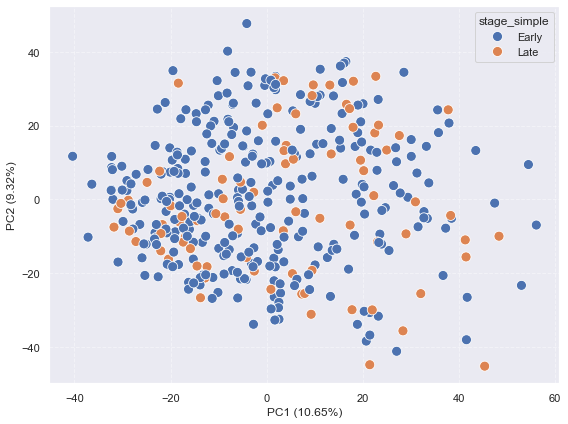

In [42]:
# ----- Plot PCA -----

# Compute gene variance across all samples (rows)
gene_variances = log2_cpm.var(axis=1)

# Select the top 500 most variable genes
top_500_genes = gene_variances.nlargest(500).index
log2_cpm_top = log2_cpm.loc[top_500_genes]

# Transpose top variable genes for PCA (samples as rows, top genes as columns)
data_transposed = log2_cpm_top.T

# Fit PCA
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(data_transposed)

# Calculate percentage of variance explained by PC1 and PC2
var_explained = pca.explained_variance_ratio_ * 100

# Store %variance explained by PC1 and PC2
pc1_var = pca.explained_variance_ratio_[0] * 100
pc2_var = pca.explained_variance_ratio_[1] * 100

# Create a DataFrame with the PCA results
pca_df = pd.DataFrame(
    pca_coords, columns=["PC1", "PC2"], index=data_transposed.index
)

# Merge clinical metadata to color points by group/condition
pca_merge = pca_df.merge(metadata_clean, left_index=True, right_on='Sample_id')

### Problem, needs right_index=True insteas!!

# Plot the PCA
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_merge,
    x="PC1",
    y="PC2",
    s=100,  # point size
    hue='stage_simple',
)

plt.xlabel(f"PC1 ({pc1_var:.2f}%)")
plt.ylabel(f"PC2 ({pc2_var:.2f}%)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()

plt.show()

In [43]:
# ----- Score PCA clustering by clinical metadata variables -----

# Define clinical variables and initialize list
clinical_cols = metadata.columns.tolist()
results = {}

# Iterate over clinical variables
for col in clinical_cols:
    if col in pca_merge.columns:
        
        # Drop missing values
        valid_data = pca_merge.dropna(subset=[col])
        
        # Exclude continuous or unique ID columns
        n_unique = valid_data[col].nunique()
        n_samples = len(valid_data)

        if 1 < n_unique < n_samples:
            X_sub = valid_data[["PC1", "PC2"]].values
            labels_sub = valid_data[col].astype(str)

            # Ensure no cluster has fewer than 2 samples
            counts = labels_sub.value_counts()
            if (counts >= 2).all():
                score = silhouette_score(X_sub, labels_sub)
                results[col] = score

# Display results ranked by cluster strength
score_df = (
    pd.DataFrame.from_dict(
        results, orient="index", columns=["Silhouette_Score"]
    ).sort_values(by="Silhouette_Score", ascending=False)
)

print(score_df)

                 Silhouette_Score
gender                   0.071488
stage_simple             0.024924
mut_KRAS                 0.024808
vital_status             0.022927
mutated_any              0.013298
mut_EGFR                -0.029267
tobacco_smoking         -0.123491


In [44]:
import numpy as np
import pandas as pd

from sklearn.decomposition import PCA
import statsmodels.api as sm
from statsmodels.formula.api import ols


def calculate_pvca(
    expr_df, meta_df, batch_factors, pct_threshold=0.80, random_effects=None
):
    """Calculates Principal Variance Component Analysis (PVCA).

    Parameters:
    -----------
    expr_df : pd.DataFrame
        Gene expression matrix (rows = samples, cols = features/genes).
    meta_df : pd.DataFrame
        Metadata table (rows = samples, cols = batch/clinical variables).
    batch_factors : list of str
        List of categorical metadata columns to evaluate (e.g., ['Batch',
        'Stage']).
    pct_threshold : float
        Proportion of total variance to retain from PCA (default 0.80 = 80%).

    Returns:
    --------
    pd.Series: Proportion of total variance explained by each factor &
    residuals.
    """
    # 1. Standardize and Run PCA
    pca = PCA()
    pcs = pca.fit_transform(expr_df)

    # 2. Select top PCs that reach the variance threshold
    explained_var = pca.explained_variance_ratio_
    cum_var = np.cumsum(explained_var)
    n_components = np.argmax(cum_var >= pct_threshold) + 1

    retained_pcs = pcs[:, :n_components]
    retained_weights = explained_var[:n_components]
    # Re-normalize weights so they sum to 1
    retained_weights /= retained_weights.sum()

    # 3. Fit Variance Component Analysis for each PC
    formula = " ~ " + " + ".join([f"C({factor})" for factor in batch_factors])

    # Dictionary to hold variance explained per factor across PCs
    factor_variances = {factor: [] for factor in batch_factors}
    factor_variances["Residuals"] = []

    for i in range(n_components):
        df_fit = meta_df[batch_factors].copy()
        df_fit["PC"] = retained_pcs[:, i]

        # Fit Ordinary Least Squares model
        model = ols("PC" + formula, data=df_fit).fit()
        anova_table = sm.stats.anova_lm(model, typ=2)

        # Calculate Sum of Squares proportions for this PC
        ss_total = anova_table["sum_sq"].sum()

        for factor in batch_factors:
            ss_factor = anova_table.loc[f"C({factor})", "sum_sq"]
            factor_variances[factor].append(ss_factor / ss_total)

        factor_variances["Residuals"].append(
            anova_table.loc["Residual", "sum_sq"] / ss_total
        )

    # 4. Weighted average across PCs by eigenvalue strength
    pvca_results = {}
    for key, var_list in factor_variances.items():
        pvca_results[key] = np.sum(np.array(var_list) * retained_weights)

    return pd.Series(pvca_results, name="PVCA_Variance_Explained")

In [123]:
# Select batch and clinical factors you want to evaluate
factors_to_test = ["mut_KRAS", "mut_EGFR", "stage_simple", "gender"]

expression_matrix = log2_cpm.T.loc[metadata_clean.index]

# Run PVCA (capturing top 80% of PCA variance)
pvca_summary = calculate_pvca(
    expr_df=expression_matrix,  # rows: samples, cols: genes/features
    meta_df=metadata_clean,  # metadata dataframe
    batch_factors=factors_to_test,
    pct_threshold=0.80,  # keep top PCs explaining 80% variance
)

print(pvca_summary)

mut_KRAS        0.007845
mut_EGFR        0.009766
stage_simple    0.006051
gender          0.016492
Residuals       0.959847
Name: PVCA_Variance_Explained, dtype: float64
